# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Aryo Dwi Haryanto
- Email: aryodwi122@gmail.com
- Id Dicoding:aryo_dwi_h

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
# Import library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

In [ ]:
# Load dataset
df = pd.read_csv('data_student.csv', sep=';')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [ ]:
print("Informasi Dataset:")
df.info()
print("\n-----------------------------------\n")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

In [ ]:
print("Pengecekan Missing Value:")
print(df.isnull().sum())
print("\n-----------------------------------\n")

Pengecekan Missing Value:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment       

**Insight:**
* ada 36 data
* Tidak ada missing value

In [ ]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


**Insight:**
* tidak ada data yang duplikasi

In [ ]:
# Melihat distribusi target
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


**Insight:**
* sebanyak 2209 data graduate
* sebanyak 1421 data dropout
* sebanyak 794 data enrolled

**Insight:**

# Exploratory Data Analysis (EDA)

In [ ]:
# Memisahkan kolom numerikal dan kategorikal untuk keperluan EDA
# Beberapa kolom di dataset ini sebenarnya kategorikal tapi di-encode sebagai angka (misal: Marital_status)
# Namun untuk kemudahan awal, kita pisahkan berdasarkan tipe data riil dan float/integer yang kontinu
numeric_cols = ['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Unemployment_rate', 'Inflation_rate', 'GDP']

categorical_cols = [col for col in df.columns if col not in numeric_cols and col != 'Status']

/tmp/ipykernel_10450/30862716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


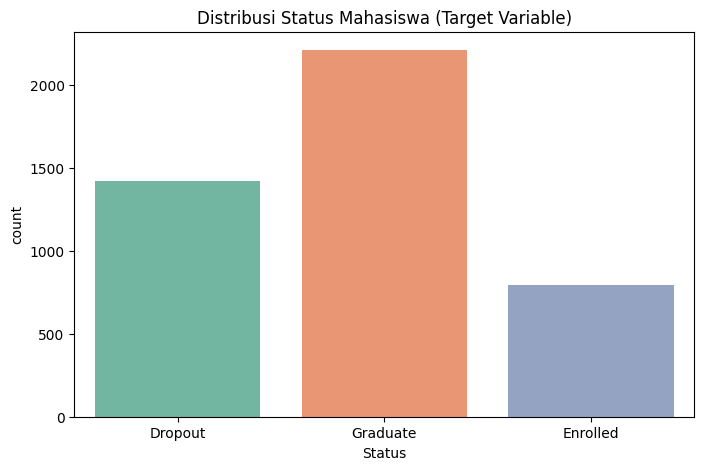

In [ ]:
# --- EDA KATEGORIKAL (Univariate) ---
# Distribusi Variabel Target (Status)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa (Target Variable)')
plt.show()

**Insight:**
1. Dominasi Lulusan (Graduate)
Kelompok mahasiswa dengan status Graduate merupakan jumlah terbanyak dalam dataset ini, mencapai lebih dari 2.200 orang.

2. Angka Dropout yang Cukup Signifikan
Status Dropout berada di posisi kedua dengan jumlah sekitar 1.400 orang. Meskipun jumlahnya di bawah angka kelulusan, angka ini tergolong cukup tinggi (lebih dari setengah jumlah lulusan).

3. Proporsi Mahasiswa Aktif (Enrolled)
Jumlah mahasiswa dengan status Enrolled (masih terdaftar/aktif) adalah yang paling sedikit, yakni di bawah 800 orang.

4. Ketidakseimbangan Data (Class Imbalance)
Terdapat perbedaan jumlah yang cukup mencolok antar kategori (misalnya, jumlah Graduate hampir 3x lipat dari Enrolled).

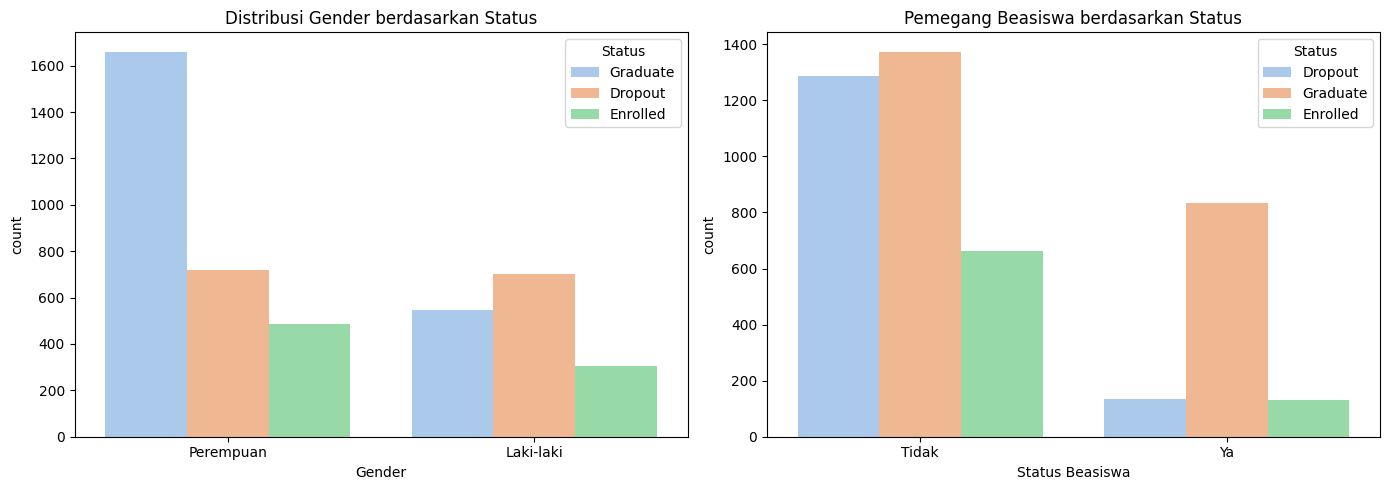

In [ ]:
# Distribusi beberapa variabel kategorikal penting (Gender & Beasiswa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gender
sns.countplot(data=df, x='Gender', hue='Status', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Gender berdasarkan Status')
axes[0].set_xlabel('Gender')
# Mengubah label 0 dan 1 menjadi Perempuan dan Laki-laki
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Perempuan', 'Laki-laki'])

# Plot 2: Beasiswa
sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[1], palette='pastel')
axes[1].set_title('Pemegang Beasiswa berdasarkan Status')
axes[1].set_xlabel('Status Beasiswa')
# Mengubah label 0 dan 1 menjadi Tidak dan Ya
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak', 'Ya'])

plt.tight_layout()
plt.show()

**Insight:**

1. Distribusi Gender berdasarkan Status

* Gender perempuan mendominasi kategori Graduate
Jumlah Graduate pada Perempuan jauh lebih tinggi dibanding Laki-laki. Ini menunjukkan perempuan memiliki tingkat kelulusan lebih baik.

* Laki-laki memiliki jumlah Dropout yang sedikit lebih tinggi dibanding Graduate.
Mengindikasikan risiko dropout lebih besar pada laki-laki.

* Enrolled relatif lebih sedikit di kedua gender
* Status Enrolled paling rendah di kedua gender.
Artinya sebagian besar mahasiswa sudah berada di tahap akhir (lulus atau dropout).

* Kesenjangan signifikan antar gender
Total mahasiswa perempuan lebih banyak dibanding Laki-laki.
Bisa mengindikasikan ketidakseimbangan populasi mahasiswa.

2. Pengaruh Beasiswa terhadap Status

* Mahasiswa tanpa beasiswa perempuan mendominasi semua status
Mayoritas mahasiswa tidak menerima beasiswa.

* Jumlah Graduate pada penerima beasiswa laki-laki jauh lebih tinggi dibanding Dropout.Mengindikasikan bahwa beasiswa membantu meningkatkan peluang lulus.

* Dropout jauh lebih rendah pada penerima beasiswa
Selisih signifikan antara Dropout non-beasiswa vs beasiswa.
Ini menunjukkan beasiswa berperan sebagai faktor protektif terhadap dropout.

* Enrolled relatif kecil pada penerima beasiswa
Kemungkinan mahasiswa penerima beasiswa lebih cepat menyelesaikan studi.

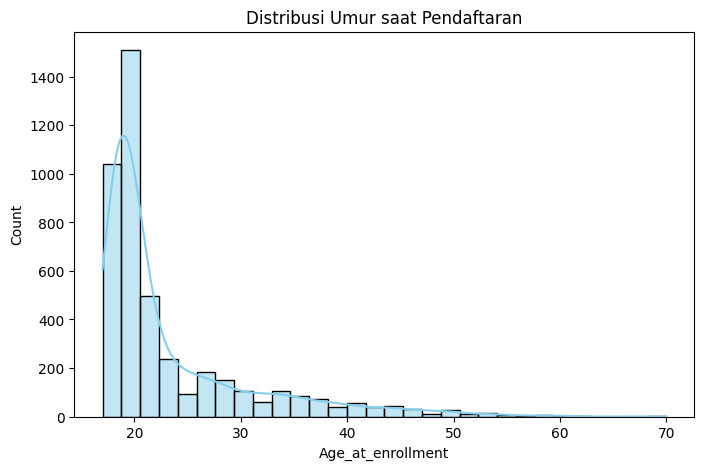

In [ ]:
# --- EDA NUMERIKAL (Univariate) ---
# Distribusi umur saat pendaftaran
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age_at_enrollment', kde=True, bins=30, color='skyblue')
plt.title('Distribusi Umur saat Pendaftaran')
plt.show()

**Insight:**
* Mayoritas mahasiswa berusia muda (18–22 tahun)
Terlihat puncak distribusi berada di rentang ini, menunjukkan sebagian besar mahasiswa mendaftar langsung setelah lulus sekolah.

* Distribusi condong ke kanan (right-skewed)
Ekor panjang ke arah usia yang lebih tua (hingga ~70 tahun) menandakan adanya sebagian kecil pendaftar usia dewasa/lansia.

* Penurunan jumlah signifikan setelah usia 25 tahun
Setelah usia awal 20-an, jumlah pendaftar menurun tajam, menunjukkan minat atau akses pendidikan lebih rendah pada kelompok usia lebih tua.

<Axes: xlabel='Status', ylabel='Curricular_units_1st_sem_grade'>

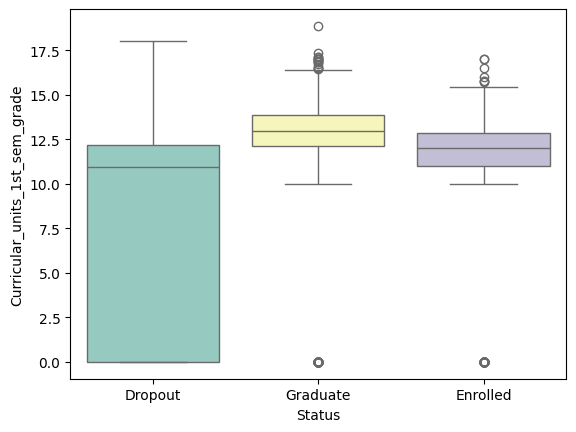

In [ ]:
# --- EDA MULTIVARIATE ---
# 1. Boxplot (Numerikal vs Kategorikal Target)
# Melihat perbedaan nilai akademik semester 1 berdasarkan status
sns.boxplot(
    data=df,
    x='Status',
    y='Curricular_units_1st_sem_grade',
    hue='Status',
    palette='Set3',
    legend=False
)

**Insight:**
* Distribusi tidak merata Sebagian besar nilai curricular units terkonsentrasi pada rentang tertentu (tidak tersebar luas).

* Ada kecenderungan dominan di nilai rendah–menengah Menunjukkan banyak mahasiswa berada pada performa akademik yang belum optimal.

* Kemungkinan skew (tidak simetris) Distribusi tampak condong ke satu sisi, indikasi adanya ketimpangan performa antar mahasiswa.

* Outlier terbatas / tidak dominan Tidak terlihat banyak nilai ekstrem, sehingga mayoritas data relatif homogen.

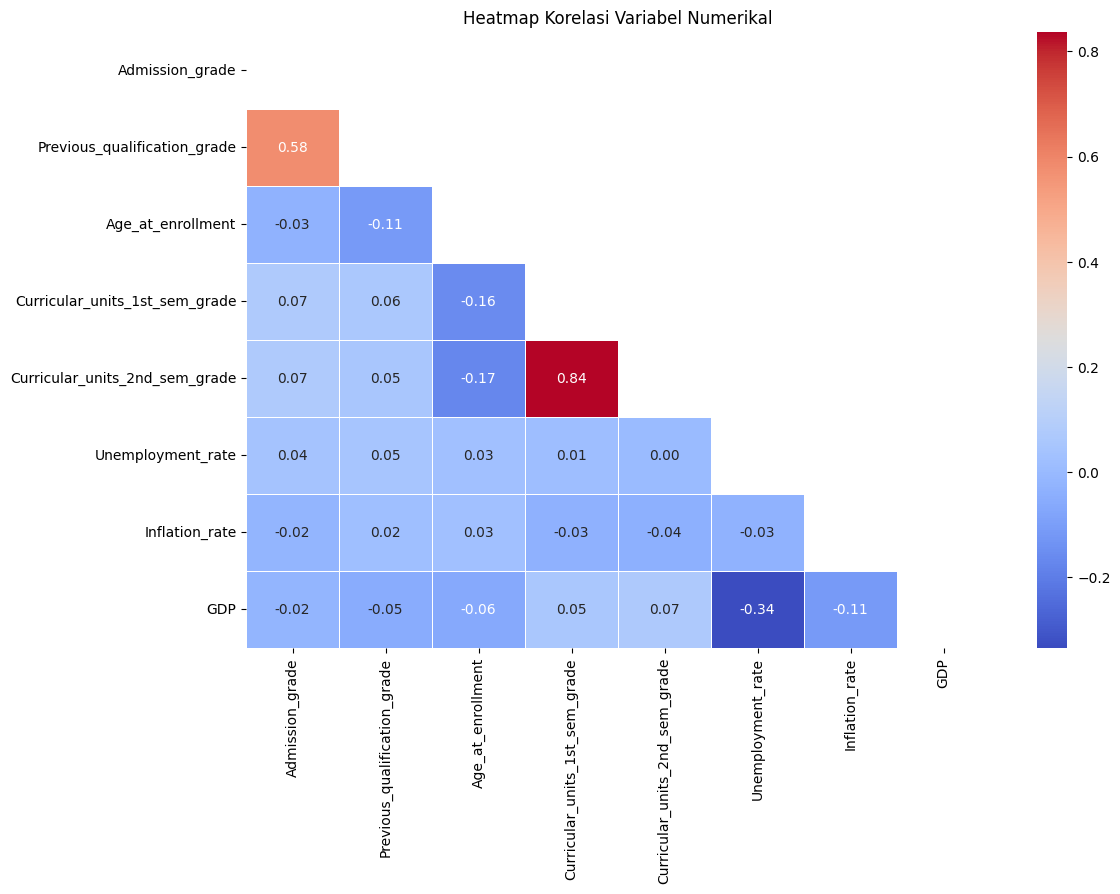

In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap Korelasi Variabel Numerikal')
plt.show()

**Insight:**
1. Curricular_units_1st_sem_grade dengan Curricular_units_2nd_sem_grade (0.84)
* Sangat kuat
* performa semester 1 sangat menentukan performa semester 2
* Bisa jadi indikator awal untuk prediksi keberhasilan mahasiswa
2. Admission_grade dengan Previous_qualification_grade (0.58)
* Korelasi sedang-kuat , nilai sebelumnya cukup konsisten dengan nilai saat masuk
* Valid sebagai indikator seleksi awal



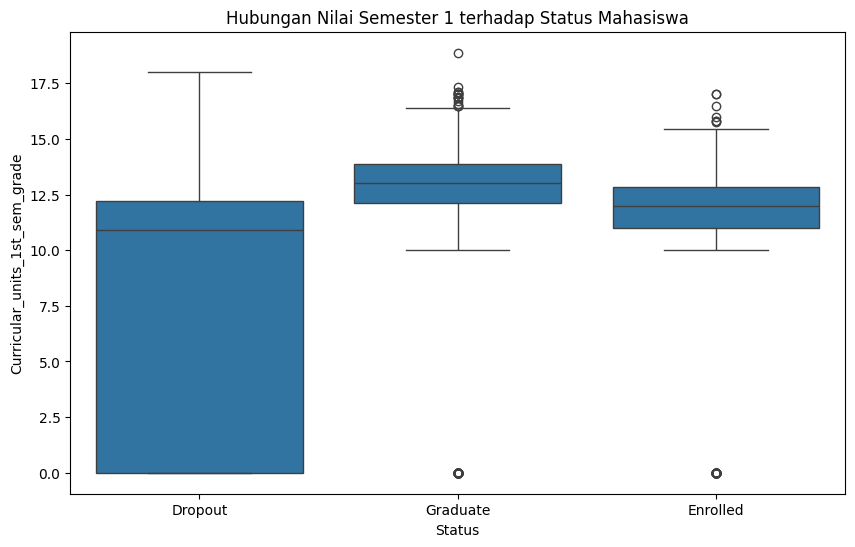

In [ ]:
# Melihat hubungan antara nilai semester 1 dengan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade')
plt.title('Hubungan Nilai Semester 1 terhadap Status Mahasiswa')
plt.show()

**Insight:**
* Korelasi Positif dengan Kelulusan: Mahasiswa dengan status Graduate (Lulus) memiliki median nilai semester 1 yang paling tinggi dibandingkan kategori lainnya (sekitar 13.0). Hal ini menunjukkan bahwa performa akademik yang baik di awal kuliah sangat menentukan keberhasilan studi.

* Indikasi Risiko Dropout: Kelompok Dropout memiliki rentang nilai yang sangat lebar dan median yang paling rendah (sekitar 11.0). Yang paling mencolok, terdapat porsi besar data yang jatuh hingga nilai 0, menunjukkan bahwa banyak mahasiswa yang langsung berhenti atau gagal total di semester pertama.

* Stabilitas Mahasiswa Aktif: Mahasiswa berkategori Enrolled (masih aktif) memiliki distribusi nilai yang lebih stabil dan terkonsentrasi di angka 11.0 hingga 13.0, serupa dengan kelompok Graduate namun sedikit lebih rendah.

## Data Preparation / Preprocessing

In [ ]:
def label_decoding(df):
    df = df.copy()

    # Mapping Marital Status
    marital_status_mapping = {
        1: 'single',
        2: 'married',
        3: 'widower',
        4: 'divorced',
        5: 'facto union',
        6: 'legally separated'
        }

    df['Marital_status'] = df['Marital_status'].map(marital_status_mapping)

    # Mapping Course
    course_mapping = {
         33: "Teknik Energi Terbarukan",
         171: "Desain Komunikasi Visual (Animasi & Multimedia)",
         8014: "Kesejahteraan Sosial (Kelas Karyawan)",
         9003: "Agroteknologi",
         9070: "Desain Komunikasi Visual",
         9085: "Kedokteran Hewan",
         9119: "Teknik Informatika",
         9130: "Peternakan",
         9147: "Manajemen",
         9238: "Kesejahteraan Sosial",
         9254: "Pariwisata",
         9500: "Ilmu Keperawatan",
         9556: "Kedokteran Gigi",
         9670: "Manajemen Pemasaran",
         9773: "Ilmu Komunikasi",
         9853: "Pendidikan Guru Sekolah Dasar (PGSD)",
         9991: "Manajemen (Kelas Karyawan)"
        }

    df['Course'] = df['Course'].map(course_mapping)

    # Mapping Attendance
    daytime_evening_mapping = {
        1: 'Kelas Siang',
        0: 'Kelas Malam'
        }
    df['Daytime_evening_attendance']=df['Daytime_evening_attendance'].map(daytime_evening_mapping)

    # Mapping Gender
    gender_mapping = {
        1: 'Laki-laki',
        0: 'Wanita'
        }
    df['Gender'] = df['Gender'].map(gender_mapping)

    return df

In [ ]:
# Buat fitur Performance: 1 untuk High, 0 untuk Low
df['Performance'] = df['Curricular_units_2nd_sem_grade'].apply(lambda x: 1 if x >= 14 else 0)

**Insight:**
* Data preparation sudah dijalankan


In [ ]:
# Simpan data asli ke variabel baru untuk dashboard
df_dashboard = label_decoding(df)

# Simpan ke CSV untuk Looker
df_dashboard.to_csv('data_untuk_looker.csv', index=False)
print("File dashboard berhasil disimpan!")

File dashboard berhasil disimpan!


In [ ]:
# 1. Filter: Hanya ambil Graduate dan Dropout
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

# 2. Encoding Target: Ubah status jadi 0 dan 1
df_model['Status'] = df_model['Status'].map({'Graduate': 0, 'Dropout': 1})

# 3. Tentukan Fitur (X) dan Target (y)
selected_features = [
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_grade',
    'Tuition_fees_up_to_date',
    'Admission_grade',
    'Age_at_enrollment',
    'Course',
    'Previous_qualification_grade',
    'Curricular_units_2nd_sem_evaluations',
    'Curricular_units_1st_sem_evaluations',
    'Fathers_occupation',
    'Scholarship_holder',
    'Gender',
    'Debtor',
]
X = df_model[selected_features]
y = df_model['Status']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()

# SEKARANG SUDAH AMAN: Tidak akan ada error "could not convert string to float"
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai! Data siap di-training.")

Preprocessing selesai! Data siap di-training.


**Insight:**
* Data siap dilatih sebanyak

# Modeling

In [ ]:
# Inisialisasi & Melatih Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Melakukan Prediksi pada data uji
y_pred = rf_model.predict(X_test_scaled)

**Insight:**
* Proses training selesai dan prediksi telah dilakukan.

## Evaluation

In [ ]:
# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model (Biner): {accuracy * 100:.2f}%\n")

Akurasi Model (Biner): 89.39%



**Insight:**
* Akurasi model sampai 89.39%

In [ ]:
# 2. Classification Report
print("Classification Report:")
target_names = ['Graduate', 'Dropout']
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

    Graduate       0.90      0.94      0.92       449
     Dropout       0.89      0.82      0.86       277

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726



**Insight:**

* Graduate (Lulus): Model sangat kuat dalam mengenali mahasiswa yang akan lulus. Nilai Recall 0.94 berarti hampir semua mahasiswa yang aslinya lulus (94%) berhasil dideteksi dengan benar oleh model.

* Dropout (Berhenti): Model sangat "hati-hati" saat menebak Dropout. Nilai Precision 0.89 berarti jika model bilang seorang mahasiswa akan dropout, tingkat kebenarannya mencapai 89%.

* Titik Lemah (Recall Dropout)
Nilai Recall Dropout (0.89) adalah yang terendah di antara metrik lainnya.

* Artinya: Masih ada sekitar 11% mahasiswa yang sebenarnya akan dropout, namun model salah menebak mereka sebagai mahasiswa yang akan lulus. Dalam konteks institusi, ini adalah kelompok "berisiko" yang gagal terdeteksi oleh sistem.

* Keseimbangan Model (F1-Score)
F1-Score kelas Graduate (0.92) lebih tinggi dibanding Dropout (0.86). Ini menunjukkan model sedikit lebih handal dalam menangani data lulusan daripada data mahasiswa yang keluar. angka 0.92 termasuk kategori sangat baik untuk model klasifikasi.


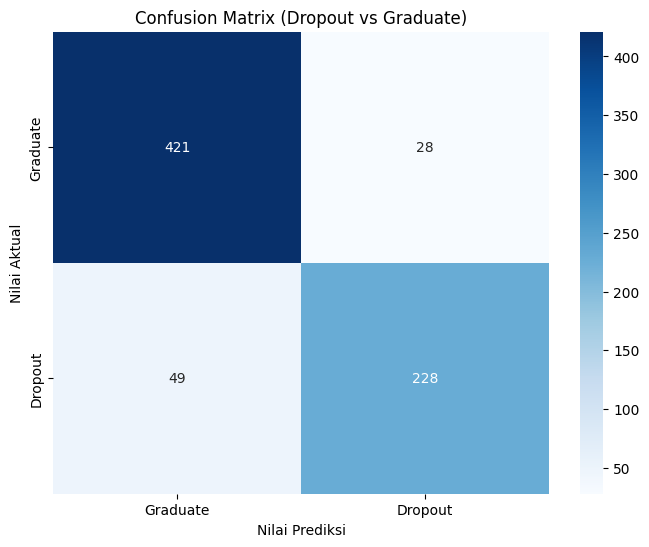

In [ ]:
# 3. Visualisasi Confusion Matrix
target_names = ['Graduate', 'Dropout']
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Dropout vs Graduate)')
plt.ylabel('Nilai Aktual')
plt.xlabel('Nilai Prediksi')
plt.show()

**Insight:**

* Akurasi Tinggi pada Graduate: Model sangat jago menebak mahasiswa yang lulus (Graduate). Ada 421 orang yang benar-benar lulus dan berhasil diprediksi dengan tepat.

* Performa Dropout: Model berhasil mendeteksi 228 orang yang berisiko Dropout.

* Kesalahan Prediksi (Miss):
28 orang yang sebenarnya Dropout, tapi malah diprediksi Graduate (ini yang perlu diwaspadai, karena mereka gagal terdeteksi sejak dini).

* 49 orang yang sebenarnya Graduate, tapi salah diprediksi akan Dropout.

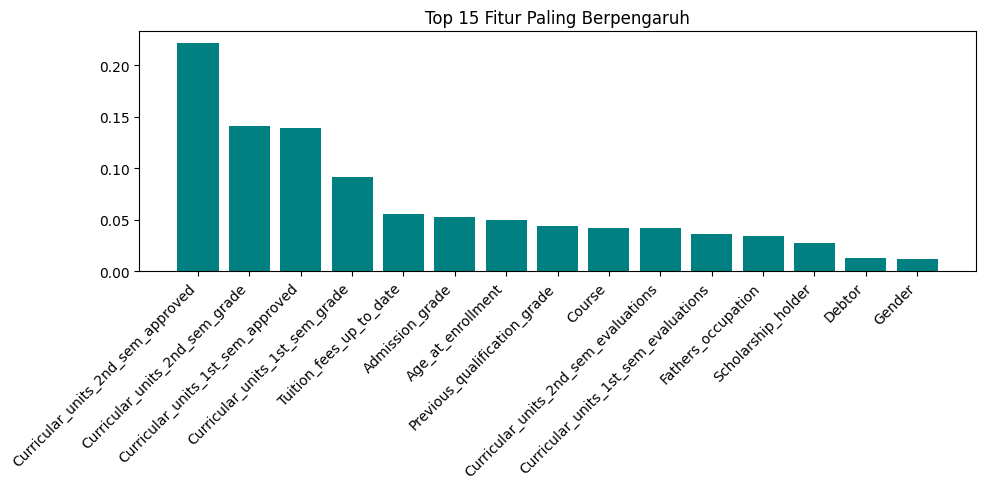


Top 15 Feature Importance:
   1. Curricular_units_2nd_sem_approved             0.2218
   2. Curricular_units_2nd_sem_grade                0.1405
   3. Curricular_units_1st_sem_approved             0.1387
   4. Curricular_units_1st_sem_grade                0.0912
   5. Tuition_fees_up_to_date                       0.0552
   6. Admission_grade                               0.0529
   7. Age_at_enrollment                             0.0493
   8. Previous_qualification_grade                  0.0437
   9. Course                                        0.0422
  10. Curricular_units_2nd_sem_evaluations          0.0422
  11. Curricular_units_1st_sem_evaluations          0.0364
  12. Fathers_occupation                            0.0338
  13. Scholarship_holder                            0.0272
  14. Debtor                                        0.0129
  15. Gender                                        0.0120


In [ ]:
# 4. Feature Importance (Pilihan)
# Melihat fitur apa yang paling berpengaruh terhadap Status mahasiswa
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns.tolist()

plt.figure(figsize=(10, 5))
plt.title("Top 15 Fitur Paling Berpengaruh")
plt.bar(range(15), importances[indices][:15], align="center", color='teal')
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 15 Feature Importance:")
for i in range(15):
    print(f"  {i+1:2d}. {feature_names[indices[i]]:<45} {importances[indices[i]]:.4f}")

1. Curricular_units_2nd_sem_approved (0,2218) merupakan variabel paling
berpengaruh, menunjukkan bahwa jumlah mata kuliah yang lulus pada semester 2 menjadi indikator utama dalam prediksi model.

2. Curricular_units_2nd_sem_grade (0,1405) dan Curricular_units_1st_sem_approved (0,1387) berada di urutan berikutnya, menandakan performa akademik pada semester awal sangat menentukan hasil prediksi.

3. Curricular_units_1st_sem_grade (0,0912) juga memiliki pengaruh cukup tinggi, sehingga kualitas nilai akademik sejak semester pertama menjadi faktor penting.

4. Tuition_fees_up_to_date (0,0552) menunjukkan bahwa status pembayaran biaya kuliah berkontribusi terhadap prediksi, sehingga faktor finansial tetap relevan.

5. Admission_grade (0,0529) dan Previous_qualification_grade (0,0437) menandakan kemampuan akademik sebelum masuk perguruan tinggi masih memiliki pengaruh terhadap outcome mahasiswa.

6. Age_at_enrollment (0,0493) menunjukkan bahwa usia saat masuk kuliah memberikan pengaruh moderat dalam model.

7. Course (0,0422) mengindikasikan bahwa program studi yang diambil juga memengaruhi hasil prediksi.

8. Curricular_units_2nd_sem_evaluations (0,0422) dan Curricular_units_1st_sem_evaluations (0,0364) menunjukkan bahwa tingkat evaluasi atau aktivitas akademik mahasiswa turut berkontribusi.

9. Fathers_occupation (0,0338) dan Scholarship_holder (0,0272) memiliki pengaruh lebih rendah, sehingga latar belakang keluarga dan status beasiswa bukan faktor utama.

10. Debtor (0,0129) dan Gender (0,0120) menjadi variabel dengan kontribusi paling kecil, sehingga faktor demografis relatif kurang menentukan dibanding performa akademik.

11. Secara keseluruhan, model lebih banyak dipengaruhi oleh kinerja akademik mahasiswa, terutama keberhasilan dan nilai pada semester 1 dan 2, dibanding faktor sosial ekonomi atau demografis.

# Tahap Deployment

In [ ]:
# Deployment (Menyimpan Model)
# Menyimpan model dan scaler untuk digunakan di aplikasi lokal
joblib.dump(rf_model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File model_rf.pkl dan scaler.pkl BERHASIL disimpan dengan kondisi sudah dilatih!")

File model_rf.pkl dan scaler.pkl BERHASIL disimpan dengan kondisi sudah dilatih!


In [ ]:
df.to_csv('data_final_baru.csv', index=False)

In [ ]:
from google.colab import files
files.download("data_final_baru.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Kesimpulan & Rekomendasi

# Kesimpulan
1. Hasil Analisis Data
Dataset terdiri dari 4.424 data mahasiswa dengan 37 variabel.
Tidak ditemukan missing value maupun duplikasi data, sehingga kualitas data tergolong baik untuk pemodelan.
Distribusi status mahasiswa:
Graduate: 2.209 mahasiswa
Dropout: 1.421 mahasiswa
Enrolled: 794 mahasiswa

Artinya, meskipun lulusan mendominasi, angka dropout masih cukup tinggi dan menjadi masalah penting yang perlu ditangani.

2. Temuan dari Exploratory Data Analysis (EDA)

Beberapa pola penting yang ditemukan yaitu: Mahasiswa dengan nilai akademik lebih tinggi, terutama semester 1 dan 2, cenderung berstatus Graduate.
Nilai semester 1 memiliki hubungan kuat dengan nilai semester 2 (korelasi tinggi ±0.84), sehingga performa awal kuliah menjadi indikator penting.
Jumlah mata kuliah yang lulus dan nilai rata-rata akademik sangat memengaruhi peluang kelulusan.
Faktor demografis seperti gender dan beasiswa juga menunjukkan pola tertentu terhadap status mahasiswa.

3. Hasil Modeling Machine Learning
Model yang digunakan adalah Random Forest Classifier, dan menghasilkan performa sangat baik:
Akurasi: 89.39%
Precision dan Recall cukup tinggi untuk kedua kelas.
Artinya, model mampu mengidentifikasi mahasiswa yang berpotensi dropout maupun lulus dengan tingkat ketepatan tinggi.

4. Faktor Paling Berpengaruh
Berdasarkan feature importance, variabel terpenting adalah:
Curricular_units_2nd_sem_approved
Nilai akademik semester 2
Jumlah mata kuliah yang diambil/lulus semester awal
Nilai semester 1
Kesimpulannya, performa akademik awal merupakan penentu utama keberhasilan studi mahasiswa.

# Rekomendasi
1. Menggunakan Sistem Early Warning untuk mengawasi Mahasiswa Berisiko
Gunakan model ini sebagai sistem deteksi dini untuk menandai mahasiswa yang berpotensi dropout sejak semester 1-2.
* Melakukan monitoring nilai rendah
* Mencatat kehadiran mahasiswa
* Mencatat mata kuliah yang tidak lulus

2. Program Pendampingan Akademik
untuk mahasiswa berisiko drop out , seperti:

* Tutor akademik
* Kelas remedial
* Konseling belajar
* Mentoring senior

3. Dukungan Finansial dan Psikologis

Jika dropout dipengaruhi faktor ekonomi/non-akademik:

* Memperbanyak beasiswa
* Memudahkan cicilan biaya kuliah
* Membuat konseling mental health
* membuat career coaching